# Notebook 02 — Feature Engineering (Kaggle, family-aware splits, sqli sweep)

Extract numeric features and character token sequences. Build family-aware
train/val/test splits for both L2A and L2B, with an sqli training-set sweep
(All / 10k / 8k / 6k / 5k) for L2B.

**Data source:** `hiwaf-processed-v1` Kaggle Dataset (attach via Add Data),
containing `csic_parsed.csv` from Notebook 01 (27,977 rows, family-aware,
CMDi split out, HttpParams label bug fixed).

In [1]:
# ── Kaggle setup (was: Mount Drive) ───────────────────────────────────────────
import sys, os
from pathlib import Path

PROJECT = "/kaggle/working"
sys.path.insert(0, PROJECT)          # so   import feature_engineering   works
os.chdir(PROJECT)                    # so relative paths behave predictably
print(f"Working dir: {os.getcwd()}")


Working dir: /kaggle/working


In [2]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl


## 0. Write `feature_engineering` package (unchanged from what you sent)

In [3]:
import os
Path("/kaggle/working/feature_engineering").mkdir(parents=True, exist_ok=True)
Path("/kaggle/working/feature_engineering/__init__.py").touch()
print("feature_engineering/ package dir created.")


feature_engineering/ package dir created.


In [4]:
%%writefile /kaggle/working/feature_engineering/extractor.py
"""
ml/feature_engineering/extractor.py

Shared numeric feature extractor used by:
  - Layer 2A training  (Isolation Forest, Shallow Autoencoder)
  - Layer 2B training  (XGBoost)
  - FastAPI inference  (app/services/layer2a_anomaly.py, layer2b_deep.py)

Rules:
  - Pure stdlib + numpy ONLY — no sklearn/torch dependency
  - Every feature is a float
  - Feature order must never change after training (ONNX is order-sensitive)
  - Add new features at the END of FEATURE_NAMES only
"""

import math
import re
from urllib.parse import urlparse, parse_qs
import numpy as np

# ── Attack pattern regexes ────────────────────────────────────────────────────

_SQLI = re.compile(
    r"\b(SELECT|UNION|INSERT|UPDATE|DELETE|DROP|ALTER|EXEC|CAST|CONVERT"
    r"|CHAR|DECLARE|WAITFOR|BENCHMARK|SLEEP)\b"
    r"|\bOR\s+\d+\s*=\s*\d+"
    r"|\bAND\s+\d+\s*=\s*\d+"
    r"|--|;|/\*|\*/|0x[0-9a-fA-F]+",
    re.IGNORECASE,
)

_XSS = re.compile(
    r"<script[\s>]|</script>"
    r"|javascript\s*:"
    r"|on\w+\s*="
    r"|<iframe[\s>]"
    r"|<img[^>]+onerror"
    r"|alert\s*\("
    r"|document\.cookie"
    r"|eval\s*\("
    r"|String\.fromCharCode",
    re.IGNORECASE,
)

_LFI = re.compile(
    r"\.\./|\.\.%2[fF]|\.\.%5[cC]"
    r"|/etc/(passwd|shadow|hosts)"
    r"|/proc/self"
    r"|boot\.ini|win\.ini"
    r"|php://|expect://|data://",
    re.IGNORECASE,
)

_OSCI = re.compile(
    r"[;&|`]\s*(ls|cat|wget|curl|bash|sh|python|perl|nc|ncat|rm|chmod|chown)"
    r"|\$\(|\$\{"
    r"|%0[aA]|%0[dD]",
    re.IGNORECASE,
)

# ── HTTP encoding maps ────────────────────────────────────────────────────────

_HTTP_METHODS = {
    "GET": 0, "POST": 1, "PUT": 2, "DELETE": 3,
    "PATCH": 4, "HEAD": 5, "OPTIONS": 6, "TRACE": 7,
}

_CONTENT_TYPES = {
    "application/json": 0,
    "application/x-www-form-urlencoded": 1,
    "multipart/form-data": 2,
    "text/plain": 3,
    "text/xml": 4,
    "application/xml": 5,
    "text/html": 6,
}

# ── Domain stripping (CRC / R2 Critical Issue 4) ──────────────────────────────
# Source datasets mix full URLs (CSIC: "http://localhost:8080/tienda1/...")
# with path-only payloads (HttpParams/PayloadBox: "/?q=..."). Left unstripped,
# url_length / path_depth / special_char_ratio etc. pick up a spurious
# "has a real host" vs "starts with /" signal that has nothing to do with
# attack content — and won't generalize past whatever host format the
# training data happened to use.
#
# Stripping to path + query (+ fragment) removes that scheme/host noise.
# Applied identically here AND in CharTokenizer's request-encoding path —
# same normalisation must run at training time and inference time, or the
# model sees a different input distribution live than it was trained on.

def strip_to_path_query(url: str) -> str:
    """
    Reduce a URL to path + query (+ fragment) only, dropping scheme/host/port.

        "http://localhost:8080/tienda1/publico/anadir.jsp?id=2"
            -> "/tienda1/publico/anadir.jsp?id=2"
        "/?q=<script>alert(1)</script>"
            -> "/?q=<script>alert(1)</script>"   (already path-only, unchanged)
    """
    if not url:
        return url
    parsed = urlparse(url)
    stripped = parsed.path or "/"
    if parsed.query:
        stripped += "?" + parsed.query
    if parsed.fragment:
        stripped += "#" + parsed.fragment
    return stripped


# ── JSON / GraphQL structural helpers (CRC Priority A) ────────────────────────
# Deliberately NOT a full JSON parser call on untrusted attack payloads —
# malformed/broken JSON is itself part of the attack surface (JSON-injection
# probing, GraphQL introspection abuse), so json.loads() would just throw on
# exactly the rows we most want a feature for. Brace/bracket counting and
# regex heuristics degrade gracefully on malformed input instead of raising.

_JSON_KEY_RE = re.compile(r'"[^"\\]*(?:\\.[^"\\]*)*"\s*:')
_GRAPHQL_OP_RE = re.compile(r"\b(query|mutation|subscription)\b\s*[\w]*\s*\{", re.IGNORECASE)
_GRAPHQL_INTROSPECTION_RE = re.compile(r"__schema|__typename|__type\b")


def _brace_nesting_depth(s: str) -> int:
    """Max nesting depth of {}/[] — works on malformed JSON/GraphQL alike."""
    depth = 0
    max_depth = 0
    for c in s:
        if c in "{[":
            depth += 1
            max_depth = max(max_depth, depth)
        elif c in "}]":
            depth = max(0, depth - 1)
    return max_depth


def _looks_like_json(body: str, content_type: str) -> bool:
    if "json" in content_type:
        return True
    b = body.strip()
    return b.startswith("{") or b.startswith("[")


def _looks_like_graphql(body: str, content_type: str) -> bool:
    if "graphql" in content_type:
        return True
    if _GRAPHQL_OP_RE.search(body):
        return True
    if _GRAPHQL_INTROSPECTION_RE.search(body):
        return True
    return False


# ── Feature names — ORDER IS FIXED, never reorder ────────────────────────────

FEATURE_NAMES = [
    # URL structure
    "url_length",              # 0
    "path_depth",              # 1
    "param_count",              # 2
    "param_value_total_len",   # 3
    "fragment_length",         # 4

    # Character ratios (computed on full URL)
    "special_char_ratio",      # 5
    "digit_ratio",             # 6
    "uppercase_ratio",         # 7
    "encoded_char_ratio",      # 8

    # Body
    "payload_length",          # 9
    "payload_entropy",         # 10

    # Attack flags (binary)
    "has_sqli",                # 11
    "has_xss",                 # 12
    "has_lfi",                 # 13
    "has_osci",                # 14

    # Attack match counts
    "sqli_match_count",        # 15
    "xss_match_count",         # 16
    "lfi_match_count",         # 17
    "osci_match_count",        # 18

    # Request metadata
    "http_method",             # 19
    "content_type",            # 20
    "header_count",            # 21
    "has_user_agent",          # 22
    "has_referer",             # 23
    "cookie_length",           # 24

    # CHANGED (CRC): JSON/GraphQL body features — appended at the END only.
    "is_json_body",            # 25  binary
    "is_graphql_operation",    # 26  binary
    "body_nesting_depth",      # 27  max {}/[] depth in body
    "body_key_count",          # 28  heuristic count of "key": pairs
]

INPUT_DIM = len(FEATURE_NAMES)   # 29 — was 25


# ── Helpers ───────────────────────────────────────────────────────────────────

def _shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    freq = {}
    for c in s:
        freq[c] = freq.get(c, 0) + 1
    n = len(s)
    return -sum((cnt / n) * math.log2(cnt / n) for cnt in freq.values())


def _ratio(count: int, total: int) -> float:
    return count / total if total > 0 else 0.0


def _encoded_char_count(s: str) -> int:
    return len(re.findall(r"%[0-9a-fA-F]{2}", s))


# ── Main extractor ────────────────────────────────────────────────────────────

def extract_features(request: dict) -> dict:
    """
    Extract a fixed-length numeric feature dict from a parsed request dict.

    Parameters
    ----------
    request : dict with keys:
        url      str   — full URL including query string
        method   str   — HTTP method (GET, POST, ...)
        headers  dict  — header name → value
        body     str   — request body (decoded)

    Returns
    -------
    dict[str, float] with keys matching FEATURE_NAMES (order preserved).
    """
    raw_url = request.get("url", "")
    url     = strip_to_path_query(raw_url)   # CHANGED: domain stripped before any feature use
    method  = request.get("method", "GET").upper().strip()
    headers = request.get("headers", {})
    body    = request.get("body", "")

    parsed   = urlparse(url)      # url is already path+query+fragment only now
    params   = parse_qs(parsed.query)
    path     = parsed.path
    fragment = parsed.fragment

    scan = url + " " + body

    url_len   = len(url)
    path_depth = len([p for p in path.split("/") if p])
    param_count = len(params)
    param_val_total = sum(len(v) for vals in params.values() for v in vals)

    special = len(re.findall(r"[<>'\"\(\);=&%+\[\]{}|\\^`~]", url))
    digits  = sum(1 for c in url if c.isdigit())
    uppers  = sum(1 for c in url if c.isupper())
    encoded = _encoded_char_count(url)

    sqli_m = _SQLI.findall(scan)
    xss_m  = _XSS.findall(scan)
    lfi_m  = _LFI.findall(scan)
    osci_m = _OSCI.findall(scan)

    headers_lower  = {k.lower(): v for k, v in headers.items()}
    cookie_len     = len(headers_lower.get("cookie", ""))
    ct_raw         = headers_lower.get("content-type", "").split(";")[0].strip().lower()
    content_type_i = _CONTENT_TYPES.get(ct_raw, len(_CONTENT_TYPES))

    # CHANGED (CRC): JSON/GraphQL structural features
    is_json    = _looks_like_json(body, ct_raw)
    is_graphql = _looks_like_graphql(body, ct_raw)
    nest_depth = _brace_nesting_depth(body)
    key_count  = len(_JSON_KEY_RE.findall(body))

    return {
        "url_length":            float(url_len),
        "path_depth":            float(path_depth),
        "param_count":           float(param_count),
        "param_value_total_len": float(param_val_total),
        "fragment_length":       float(len(fragment)),
        "special_char_ratio":    _ratio(special, url_len),
        "digit_ratio":           _ratio(digits, url_len),
        "uppercase_ratio":       _ratio(uppers, url_len),
        "encoded_char_ratio":    _ratio(encoded, url_len),
        "payload_length":        float(len(body)),
        "payload_entropy":       _shannon_entropy(body),
        "has_sqli":              float(bool(sqli_m)),
        "has_xss":               float(bool(xss_m)),
        "has_lfi":               float(bool(lfi_m)),
        "has_osci":              float(bool(osci_m)),
        "sqli_match_count":      float(len(sqli_m)),
        "xss_match_count":       float(len(xss_m)),
        "lfi_match_count":       float(len(lfi_m)),
        "osci_match_count":      float(len(osci_m)),
        "http_method":           float(_HTTP_METHODS.get(method, 8)),
        "content_type":          float(content_type_i),
        "header_count":          float(len(headers)),
        "has_user_agent":        float("user-agent" in headers_lower),
        "has_referer":           float("referer" in headers_lower),
        "cookie_length":         float(cookie_len),

        # CHANGED (CRC): appended at end, matches FEATURE_NAMES order
        "is_json_body":          float(is_json),
        "is_graphql_operation":  float(is_graphql),
        "body_nesting_depth":    float(nest_depth),
        "body_key_count":        float(key_count),
    }


def to_vector(features: dict) -> np.ndarray:
    """Convert feature dict → numpy float32 row vector of shape (1, INPUT_DIM)."""
    return np.array(
        [features[k] for k in FEATURE_NAMES], dtype=np.float32
    ).reshape(1, -1)


def extract_vector(request: dict) -> np.ndarray:
    """Convenience: extract_features + to_vector in one call."""
    return to_vector(extract_features(request))

Writing /kaggle/working/feature_engineering/extractor.py


In [5]:
%%writefile /kaggle/working/feature_engineering/normalizer.py
"""
ml/feature_engineering/normalizer.py

Wraps sklearn StandardScaler with save/load so the SAME scaler
fitted on training data is used at inference time.

Why a separate file?
--------------------
Isolation Forest and the Shallow Autoencoder both need scaled features.
XGBoost is tree-based (scale-invariant) but we scale it anyway so the
pipeline is consistent and the same scaler can be reused everywhere.

The scaler is fitted ONCE on the training split and saved to disk.
At FastAPI startup it is loaded alongside the ONNX model.

Usage
-----
Training:
    norm = Normalizer()
    X_train_scaled = norm.fit(X_train)
    X_val_scaled   = norm.transform(X_val)
    norm.save("ml/exported_models/scaler_l2a.pkl")

Inference:
    norm = Normalizer.load("ml/exported_models/scaler_l2a.pkl")
    X_scaled = norm.transform(feature_vector)
"""

import numpy as np
import joblib  # type: ignore
from pathlib import Path
from sklearn.preprocessing import StandardScaler


class Normalizer:
    """Thin wrapper around StandardScaler with save/load helpers."""

    def __init__(self):
        self._scaler = StandardScaler()
        self._fitted = False

    # ── fit ───────────────────────────────────────────────────────────────────

    def fit(self, X: np.ndarray) -> np.ndarray:
        """
        Fit scaler on X and return scaled X.
        Call ONLY on training data — never on val/test.
        """
        X_scaled    = self._scaler.fit_transform(X.astype(np.float32))
        self._fitted = True
        return X_scaled.astype(np.float32)

    # ── transform ─────────────────────────────────────────────────────────────

    def transform(self, X: np.ndarray) -> np.ndarray:
        """Apply fitted scaler to X. Must call fit() first."""
        if not self._fitted:
            raise RuntimeError("Normalizer not fitted. Call fit() first.")
        return self._scaler.transform(X.astype(np.float32)).astype(np.float32)

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """Fit and transform in one call (convenience)."""
        return self.fit(X)

    # ── stats (for reporting) ─────────────────────────────────────────────────

    @property
    def mean_(self) -> np.ndarray:
        return self._scaler.mean_ # type: ignore

    @property
    def scale_(self) -> np.ndarray:
        return self._scaler.scale_ # type: ignore

    def feature_stats(self, feature_names: list) -> dict:
        """Return mean and std per feature — useful for sanity-checking."""
        return {
            name: {"mean": float(m), "std": float(s)}
            for name, m, s in zip(feature_names, self.mean_, self.scale_)
        }

    # ── persistence ───────────────────────────────────────────────────────────

    def save(self, path: str):
        """Save fitted scaler to disk as a .pkl file."""
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self._scaler, path)
        print(f"[Normalizer] Saved to {path}")

    @classmethod
    def load(cls, path: str) -> "Normalizer":
        """Load a previously saved scaler from disk."""
        norm = cls()
        norm._scaler = joblib.load(path)
        norm._fitted = True
        print(f"[Normalizer] Loaded from {path}")
        return norm

Writing /kaggle/working/feature_engineering/normalizer.py


In [6]:
%%writefile /kaggle/working/feature_engineering/tokenizer.py
"""
ml/feature_engineering/tokenizer.py

Character-level tokeniser for Layer 2B sequence models (1D CNN, GRU).
XGBoost uses extractor.py numeric vectors instead — NOT this file.

Design
------
- Vocabulary: printable ASCII characters that appear in HTTP traffic
- Index 0  : PAD  (padding token, masked in attention / ignored in pool)
- Index 1–N: real characters
- Index N+1: UNK  (characters outside vocab)

Stateless — safe to instantiate once at app startup and reuse.

Used in
-------
  Training  : ml/layer2b/candidates/cnn_1d.py, gru.py
  Inference : app/services/layer2b_deep.py
"""

import numpy as np
from typing import Union
from .extractor import strip_to_path_query 

# ── Vocabulary ────────────────────────────────────────────────────────────────
# Covers every character commonly seen in HTTP request URLs and bodies.
# Order must never change after training.

_CHARS = (
    "abcdefghijklmnopqrstuvwxyz"
    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "0123456789"
    " .,;:!?@#$%^&*()-_=+[]{}|/<>\\\"'`~\n\t\r"
)

PAD_IDX   = 0
_CHAR2IDX = {c: i + 1 for i, c in enumerate(_CHARS)}   # 1-indexed
VOCAB_SIZE = len(_CHARS) + 1                            # +1 for PAD
UNK_IDX   = VOCAB_SIZE                                  # out-of-vocab → end


class CharTokenizer:
    """
    Stateless character-level tokeniser.

    Parameters
    ----------
    max_len : int
        Sequence length. Strings longer than max_len are truncated from
        the RIGHT (we keep the start — method + URL start — which contains
        the most attack signal). Shorter strings are right-padded with PAD_IDX.
    """

    def __init__(self, max_len: int = 512):
        self.max_len    = max_len
        self.vocab_size = VOCAB_SIZE
        self._c2i       = _CHAR2IDX

    # ── single sample ─────────────────────────────────────────────────────────

    def encode(self, text: str, pad: bool = True) -> np.ndarray:
        """
        Encode a single string → int32 array of shape (max_len,).

        Characters not in vocabulary map to UNK_IDX.
        """
        indices = [self._c2i.get(c, UNK_IDX) for c in text[: self.max_len]]
        if pad:
            indices += [PAD_IDX] * max(0, self.max_len - len(indices))
        return np.array(indices, dtype=np.int32)

    def encode_request(self, request: dict) -> np.ndarray:
        """
        Build canonical request string and encode it.

        Format: "METHOD URL BODY"
        The space separators act as natural delimiters between sections.
        """
        text = (
            request.get("method", "GET") + " "
            + strip_to_path_query(request.get("url", "")) + " "
            + request.get("body", "")
        )
        return self.encode(text, pad=True)

    # ── batch ─────────────────────────────────────────────────────────────────

    def encode_batch(self, texts: list[str]) -> np.ndarray:
        """Encode list of strings → (N, max_len) int32 array."""
        return np.stack([self.encode(t) for t in texts])

    def encode_requests(self, requests: list[dict]) -> np.ndarray:
        """Encode list of request dicts → (N, max_len) int32 array."""
        texts = [
            r.get("method", "GET") + " "
            + strip_to_path_query(r.get("url", "")) + " "   # CHANGED
            + r.get("body", "")
            for r in requests
        ]
        return self.encode_batch(texts)

    # ── decode (for debugging / attention visualisation) ──────────────────────

    def decode(self, indices: Union[list, np.ndarray]) -> str:
        """Decode int indices back to string, stopping at first PAD."""
        idx2char = {v: k for k, v in self._c2i.items()}
        chars = []
        for i in indices:
            i = int(i)
            if i == PAD_IDX:
                break
            chars.append(idx2char.get(i, "?"))
        return "".join(chars)

    def __repr__(self) -> str:
        return f"CharTokenizer(vocab_size={self.vocab_size}, max_len={self.max_len})"

Writing /kaggle/working/feature_engineering/tokenizer.py


## 1. Load data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from feature_engineering.extractor import extract_features, to_vector, FEATURE_NAMES, INPUT_DIM, strip_to_path_query
from feature_engineering.tokenizer import CharTokenizer
from feature_engineering.normalizer import Normalizer   # FIX: was FeatureNormalizer — that class doesn't exist
from sklearn.model_selection import GroupShuffleSplit

# FIX: fresh-session Kaggle input, per your Add Data setup
DATA_PROC  = Path("/kaggle/input/datasets/surathbob/hiwaf-processed-v1")
SPLITS_DIR = Path("/kaggle/working/data/splits")
OUT_DIR    = Path("/kaggle/working/data/processed")
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROC / "csic_parsed.csv")
df = df.reset_index(drop=True)   # ensure clean 0..N-1 index — split logic below relies on this
print(f"Loaded {len(df):,} records")

# FIX: guard threshold was 20,000 — stale from before the HttpParams label
# bug fix (Notebook 01). Correct balanced dataset is now 27,977 rows.
if len(df) > 35000:
    print(f"  \u26a0\ufe0f  WARNING: {len(df):,} rows loaded — looks like the UNBALANCED dataset.")
    print("     Re-run Notebook 01 (all cells including the balance cell) before continuing.")
else:
    print(f"  \u2705 Balanced dataset confirmed ({len(df):,} rows)")

assert "family_id" in df.columns, "family_id missing — re-run Notebook 01's family_id cell."

print(df["attack_class"].value_counts())


Loaded 25,719 records
  ✅ Balanced dataset confirmed (25,719 rows)
attack_class
sqli            12855
normal           5000
other_attack     3003
lfi              3000
xss              1861
Name: count, dtype: int64


## 2. Extract numeric features for all records

**Known limitation, deferred (not fixed here):** `headers` was never captured
by any Notebook 01 parser, so `header_count`, `has_user_agent`, `has_referer`,
`cookie_length`, and `content_type` (5 of 25 features) will be constant
across every row. Confirmed harmless to training (no crash, just 5 wasted
dimensions) — flagged as a known limitation rather than fixed now.

In [8]:
import json
import ast
from tqdm import tqdm

feature_rows = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    raw_headers = row.get("headers", {})   # will be {} for every row — see note above

    if isinstance(raw_headers, str):
        try:
            headers_dict = json.loads(raw_headers.replace("'", '"'))
        except Exception:
            try:
                headers_dict = ast.literal_eval(raw_headers)
            except Exception:
                headers_dict = {}
    else:
        headers_dict = raw_headers if isinstance(raw_headers, dict) else {}

    req = {
        "url":     str(row.get("url", "")),
        "method":  str(row.get("method", "GET")),
        "headers": headers_dict,
        "body":    str(row.get("body", "")),
    }
    feature_rows.append(extract_features(req))

df_feat = pd.DataFrame(feature_rows)
df_feat["label_id"]        = df["label_id"].values
df_feat["attack_class_id"] = df["attack_class_id"].values
df_feat["attack_class"]    = df["attack_class"].values
df_feat["family_id"]       = df["family_id"].values   # CHANGED: propagated for family-aware splitting below

print(df_feat.shape)
df_feat.head()


Extracting features: 100%|██████████| 25719/25719 [00:04<00:00, 5473.25it/s]


(25719, 33)


,url_length,path_depth,param_count,param_value_total_len,fragment_length,special_char_ratio,digit_ratio,uppercase_ratio,encoded_char_ratio,payload_length,...,has_referer,cookie_length,is_json_body,is_graphql_operation,body_nesting_depth,body_key_count,label_id,attack_class_id,attack_class,family_id
0,79.0,3.0,3.0,35.0,0.0,0.088608,0.101266,0.075949,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,normal,4c4eb3b2d35f
1,39.0,0.0,1.0,35.0,0.0,0.102564,0.307692,0.000000,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,sqli,8539aa72ff9b
2,18.0,0.0,1.0,10.0,0.0,0.055556,0.000000,0.000000,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,3,lfi,2396c27212f3
3,12.0,0.0,1.0,4.0,0.0,0.250000,0.000000,0.000000,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,3,lfi,52b276313930
4,222.0,0.0,1.0,218.0,0.0,0.216216,0.261261,0.000000,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,sqli,a744eaa85660


## 3. Visualise feature distributions

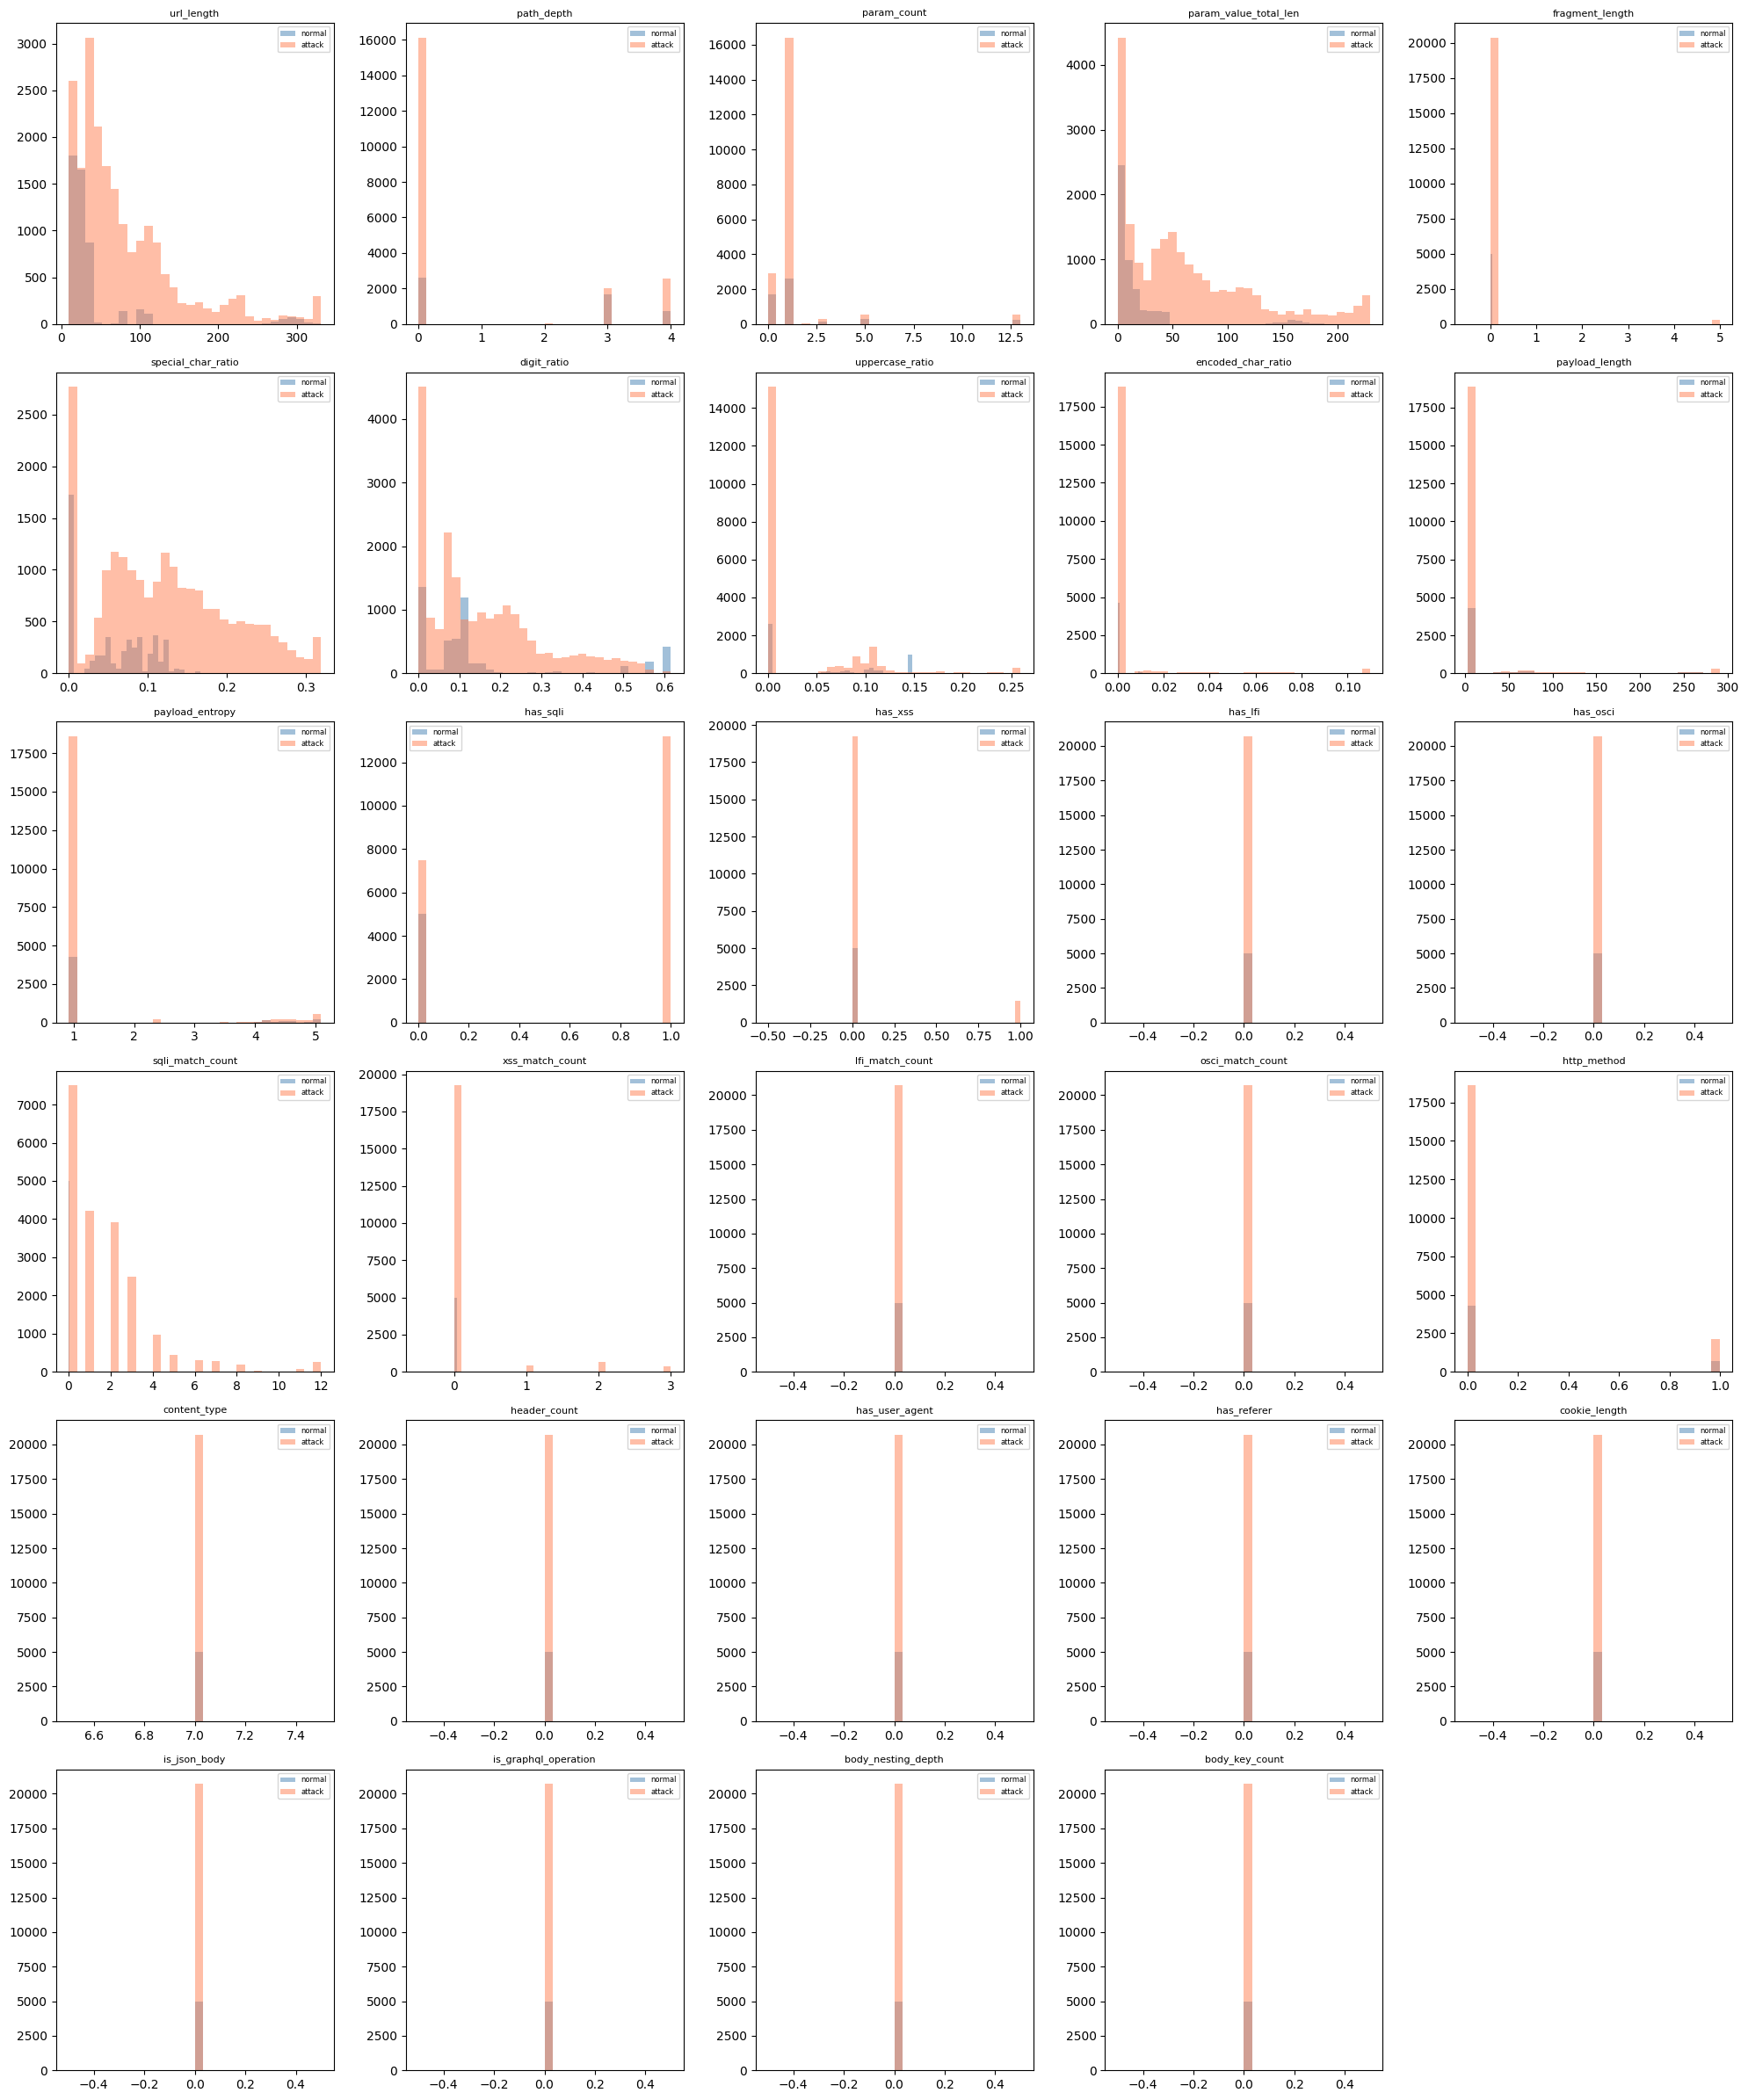

In [9]:
import math
import matplotlib.pyplot as plt

num_features = len(FEATURE_NAMES)
cols = 5
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes_flat = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes_flat[i]
    for label_id, color in [(0, "steelblue"), (1, "coral")]:
        subset = df_feat[df_feat["label_id"] == label_id][feat]
        if not subset.empty:
            vals = subset.clip(df_feat[feat].quantile(0.01),
                               df_feat[feat].quantile(0.99))
            ax.hist(vals, bins=30, alpha=0.5, color=color,
                    label="normal" if label_id == 0 else "attack")
    ax.set_title(feat, fontsize=8)
    ax.legend(fontsize=6)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "02_feature_distributions.png", dpi=100)   # FIX: Kaggle path
plt.show()


## 4. Correlation heatmap

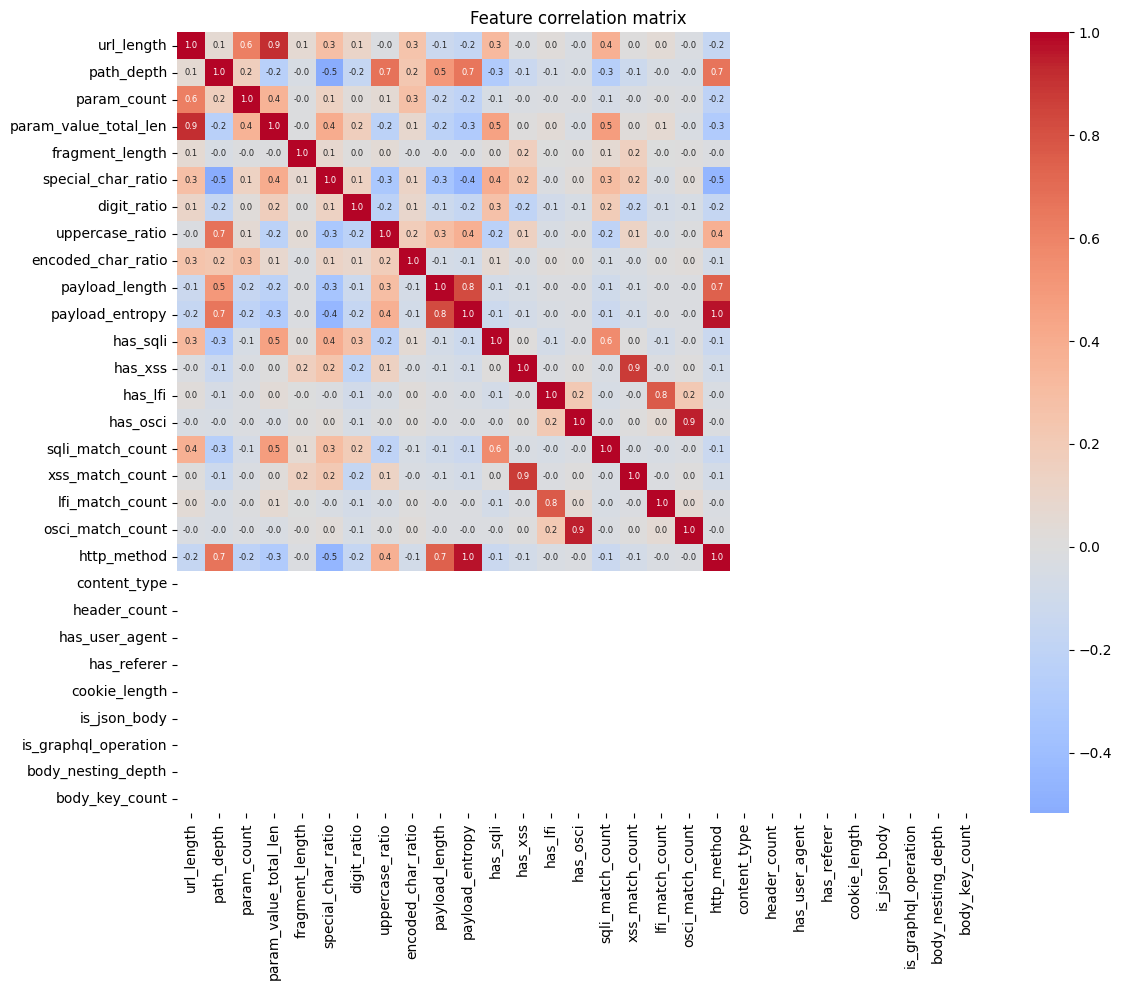

In [10]:
corr = df_feat[FEATURE_NAMES].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            annot_kws={"size": 6})
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_correlation.png", dpi=100)   # FIX: Kaggle path
plt.show()


## 5. Family-aware stratified split helper

**NEW.** Replaces plain `train_test_split` everywhere below. Splits by
`family_id` (via `GroupShuffleSplit`) so no payload family straddles
train/val/test, while still approximately preserving class proportions —
done per-class, since `GroupShuffleSplit` alone has no `stratify` option.

Class proportions across splits will be *approximate*, not exact, since
group boundaries take priority over perfect stratification. This is
expected and correct: it's the same trade-off the paper's reviewers were
implicitly asking for when they flagged leakage risk.

In [11]:
def group_stratified_split(frame, group_col, class_col,
                            train_size=0.70, val_size=0.15, test_size=0.15,
                            seed=42):
    """Per-class, family-grouped train/val/test split.

    Returns (train_idx, val_idx, test_idx) — lists of `frame` index labels.
    No family_id ever appears in more than one of the three returned sets.
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6

    train_idx, val_idx, test_idx = [], [], []
    rel_val = val_size / (val_size + test_size)

    for cls in frame[class_col].unique():
        cls_df = frame[frame[class_col] == cls]

        # Some classes may have very few families (e.g. cmdi) — guard against
        # GroupShuffleSplit failing when there aren't enough groups to split.
        n_groups = cls_df[group_col].nunique()
        if n_groups < 3:
            # Too few families to split meaningfully — keep entirely in train
            print(f"  [{cls}] only {n_groups} families — keeping all in train, none in val/test")
            train_idx.extend(cls_df.index.tolist())
            continue

        gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
        tr_i, temp_i = next(gss1.split(cls_df, groups=cls_df[group_col]))
        temp_df = cls_df.iloc[temp_i]

        if temp_df[group_col].nunique() < 2:
            # Not enough families left to split val/test — put remainder in val
            val_idx.extend(temp_df.index.tolist())
            train_idx.extend(cls_df.iloc[tr_i].index.tolist())
            continue

        gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=seed)
        v_i, te_i = next(gss2.split(temp_df, groups=temp_df[group_col]))

        train_idx.extend(cls_df.iloc[tr_i].index.tolist())
        val_idx.extend(temp_df.iloc[v_i].index.tolist())
        test_idx.extend(temp_df.iloc[te_i].index.tolist())

    return train_idx, val_idx, test_idx


def cap_by_family(frame, group_col, cap, seed=42):
    """Family-safe subsampling — same logic as Notebook 01's capping.
    Returns index labels, never splitting a family across the cap boundary.
    Prints a warning and returns everything if cap exceeds available rows
    (rather than silently pretending the cap was met).
    """
    if cap is None or len(frame) <= cap:
        if cap is not None and len(frame) < cap:
            print(f"    NOTE: requested cap {cap:,} exceeds available {len(frame):,} rows — using all available.")
        return frame.index.tolist()

    rng = np.random.RandomState(seed)
    families = frame[group_col].astype(object).to_numpy()  # FIX: avoids pandas StringArray shuffle warning
    families = pd.unique(families)
    rng.shuffle(families)

    kept, running = [], 0
    for fam in families:
        if running >= cap:
            break
        fam_rows = frame[frame[group_col] == fam]
        kept.append(fam)
        running += len(fam_rows)

    return frame[frame[group_col].isin(kept)].index.tolist()

print("group_stratified_split() and cap_by_family() defined.")

def group_two_way_split(frame, group_col, class_col, size_a=0.5, size_b=0.5, seed=42):
    """Two-way family-grouped split (e.g. val/test only, no train branch).
    Avoids GroupShuffleSplit(train_size=0.0), which raises ValueError —
    confirmed by direct test, not assumed.
    """
    assert abs(size_a + size_b - 1.0) < 1e-6
    a_idx, b_idx = [], []
    for cls in frame[class_col].unique():
        cls_df = frame[frame[class_col] == cls]
        n_groups = cls_df[group_col].nunique()
        if n_groups < 2:
            print(f"  [{cls}] only {n_groups} families — keeping all in first split half")
            a_idx.extend(cls_df.index.tolist())
            continue
        gss = GroupShuffleSplit(n_splits=1, train_size=size_a, random_state=seed)
        i_a, i_b = next(gss.split(cls_df, groups=cls_df[group_col]))
        a_idx.extend(cls_df.iloc[i_a].index.tolist())
        b_idx.extend(cls_df.iloc[i_b].index.tolist())
    return a_idx, b_idx

print("group_two_way_split() defined.")


group_stratified_split() and cap_by_family() defined.
group_two_way_split() defined.


## 6. Build Layer 2A splits (family-aware)

Same design as before — separate normal-val / attack-val (not mixed, so FPR
and TPR are measured independently, per the earlier documented fix) — now
routed through `group_stratified_split` on `family_id` instead of plain
`train_test_split`.

In [12]:
X_all = df_feat[FEATURE_NAMES].values.astype(np.float32)

# Split normal-only and attack-only pools independently, family-aware
df_normal = df_feat[df_feat["label_id"] == 0]
df_attack = df_feat[df_feat["label_id"] == 1]

# Normal: 70% train / 15% val / 15% test, family-grouped
# (single "class" here — normal — so pass a constant class_col)
df_normal = df_normal.assign(_cls="normal")
n_tr_idx, n_val_idx, n_test_idx = group_stratified_split(
    df_normal, group_col="family_id", class_col="_cls",
    train_size=0.70, val_size=0.15, test_size=0.15, seed=42
)

# Attack: split into val/test only (no attack rows in L2A training —
# it's a one-class model), 50/50, family-grouped.
# FIX: originally called group_stratified_split with train_size=0.0 to force
# an empty train branch — tested directly and confirmed this raises
# ValueError in GroupShuffleSplit (0.0 is not a valid train_size). Using a
# dedicated two-way helper instead.
df_attack = df_attack.assign(_cls="attack")
a_val_idx, a_test_idx = group_two_way_split(
    df_attack, group_col="family_id", class_col="_cls",
    size_a=0.50, size_b=0.50, seed=42
)
assert len(a_val_idx) > 0 and len(a_test_idx) > 0, "Attack val/test split failed — check family counts."

X_n_train = df_feat.loc[n_tr_idx, FEATURE_NAMES].values.astype(np.float32)
X_n_val   = df_feat.loc[n_val_idx, FEATURE_NAMES].values.astype(np.float32)
X_n_test  = df_feat.loc[n_test_idx, FEATURE_NAMES].values.astype(np.float32)
X_attack_val  = df_feat.loc[a_val_idx, FEATURE_NAMES].values.astype(np.float32)
X_attack_test = df_feat.loc[a_test_idx, FEATURE_NAMES].values.astype(np.float32)

# Mixed test set (normal_test + attack_test), shuffled
X_test_l2a = np.vstack([X_n_test, X_attack_test])
y_test_l2a = np.array([0]*len(X_n_test) + [1]*len(X_attack_test), dtype=int)
idx = np.random.RandomState(42).permutation(len(X_test_l2a))
X_test_l2a, y_test_l2a = X_test_l2a[idx], y_test_l2a[idx]

np.save(SPLITS_DIR / "l2a_normal_train.npy", X_n_train)
np.save(SPLITS_DIR / "l2a_normal_val.npy",   X_n_val)      # normal only — for FPR
np.save(SPLITS_DIR / "l2a_attack_val.npy",   X_attack_val) # attack only — for TPR
np.save(SPLITS_DIR / "l2a_test_X.npy",       X_test_l2a)
np.save(SPLITS_DIR / "l2a_test_y.npy",       y_test_l2a)

print("L2A splits (family-aware):")
print(f"  train  (normal only):  {X_n_train.shape}")
print(f"  val    (normal only):  {X_n_val.shape}     \u2190 for FPR measurement")
print(f"  val    (attack only):  {X_attack_val.shape} \u2190 for TPR measurement")
print(f"  test   (mixed):        {X_test_l2a.shape}  attack_rate={y_test_l2a.mean():.1%}")


L2A splits (family-aware):
  train  (normal only):  (3791, 29)
  val    (normal only):  (606, 29)     ← for FPR measurement
  val    (attack only):  (10533, 29) ← for TPR measurement
  test   (mixed):        (10789, 29)  attack_rate=94.4%


## 7. Build Layer 2B splits (family-aware, multiclass) + sqli sweep

Fixed test/val set carved out once (family-aware, per-class). The sqli
sweep (All / 10k / 8k / 6k / 5k) is then applied **only to the training
partition** — val/test stay identical across all 5 sweep points, so
Macro F1 comparisons across sweep runs are apples-to-apples.

**Note on sweep target 10k:** total sqli pool is 12,855 rows; a 70% train
split leaves roughly ~9,000 available for training. A "10k" target
therefore exceeds what's available — `cap_by_family` will print a warning
and fall back to "keep all" for that point rather than silently succeeding
with a number that was never actually reached.

In [13]:
y_mc = df_feat["attack_class_id"].values.astype(int)

tr_idx, val_idx, test_idx = group_stratified_split(
    df_feat, group_col="family_id", class_col="attack_class_id",
    train_size=0.70, val_size=0.15, test_size=0.15, seed=42
)

df_train = df_feat.loc[tr_idx]
df_val   = df_feat.loc[val_idx]
df_test  = df_feat.loc[test_idx]

print(f"Fixed L2B split sizes — train: {len(df_train):,}  val: {len(df_val):,}  test: {len(df_test):,}")
print("Train class counts:")
print(df_train["attack_class"].value_counts())

# Save the fixed val/test numeric splits (identical across all sweep points)
X_v  = df_val[FEATURE_NAMES].values.astype(np.float32)
X_te = df_test[FEATURE_NAMES].values.astype(np.float32)
y_v  = df_val["attack_class_id"].values.astype(int)
y_te = df_test["attack_class_id"].values.astype(int)

np.save(SPLITS_DIR / "l2b_val_X_numeric.npy",  X_v)
np.save(SPLITS_DIR / "l2b_test_X_numeric.npy", X_te)
np.save(SPLITS_DIR / "l2b_val_y.npy",  y_v)
np.save(SPLITS_DIR / "l2b_test_y.npy", y_te)

# ── sqli sweep on the TRAINING partition only ──────────────────────────────
SQLI_SWEEP = [None, 10000, 8000, 6000, 5000]   # None = keep all

df_train_sqli   = df_train[df_train["attack_class"] == "sqli"]
df_train_others = df_train[df_train["attack_class"] != "sqli"]

print(f"\nTraining partition sqli pool available: {len(df_train_sqli):,} rows")
print(f"Non-sqli training rows (unchanged across all sweep points): {len(df_train_others):,}\n")

sweep_summary = []
for cap in SQLI_SWEEP:
    label = "all" if cap is None else f"{cap//1000}k"
    print(f"[sweep: sqli={label}]")
    sqli_idx = cap_by_family(df_train_sqli, group_col="family_id", cap=cap, seed=42)

    combined_idx = df_train_others.index.tolist() + sqli_idx
    df_sweep = df_feat.loc[combined_idx]

    X_tr_sweep = df_sweep[FEATURE_NAMES].values.astype(np.float32)
    y_tr_sweep = df_sweep["attack_class_id"].values.astype(int)

    np.save(SPLITS_DIR / f"l2b_train_X_numeric_sqli{label}.npy", X_tr_sweep)
    np.save(SPLITS_DIR / f"l2b_train_y_sqli{label}.npy", y_tr_sweep)
    # Also save the index list — needed by the token cell below to build
    # matching token arrays for the same rows.
    np.save(SPLITS_DIR / f"l2b_train_idx_sqli{label}.npy", np.array(combined_idx))

    actual_sqli_n = len(sqli_idx)
    print(f"  total train rows: {len(combined_idx):,}  (sqli: {actual_sqli_n:,})")
    sweep_summary.append({"sweep_point": label, "target": cap, "actual_sqli_rows": actual_sqli_n,
                          "total_train_rows": len(combined_idx)})

sweep_df = pd.DataFrame(sweep_summary)
sweep_df.to_csv(SPLITS_DIR / "sqli_sweep_summary.csv", index=False)
print("\nSweep summary:")
print(sweep_df.to_string(index=False))


Fixed L2B split sizes — train: 18,070  val: 3,956  test: 3,693
Train class counts:
attack_class
sqli            9012
normal          3791
lfi             2103
other_attack    1866
xss             1298
Name: count, dtype: int64

Training partition sqli pool available: 9,012 rows
Non-sqli training rows (unchanged across all sweep points): 9,058

[sweep: sqli=all]
  total train rows: 18,070  (sqli: 9,012)
[sweep: sqli=10k]
    NOTE: requested cap 10,000 exceeds available 9,012 rows — using all available.
  total train rows: 18,070  (sqli: 9,012)
[sweep: sqli=8k]
  total train rows: 17,058  (sqli: 8,000)
[sweep: sqli=6k]
  total train rows: 15,058  (sqli: 6,000)
[sweep: sqli=5k]
  total train rows: 14,058  (sqli: 5,000)

Sweep summary:
sweep_point  target  actual_sqli_rows  total_train_rows
        all     NaN              9012             18070
        10k 10000.0              9012             18070
         8k  8000.0              8000             17058
         6k  6000.0              6

## 8. Build character token sequences for CNN / GRU

Encodes the whole dataset once, then slices by the *same* index sets used
for the numeric splits above (fixed val/test, plus one array per sqli
sweep point) — guarantees numeric and token arrays stay row-aligned.

In [14]:
tok = CharTokenizer(max_len=512)

def row_to_text(row):
    return (str(row.get("method","GET")) + " "
            + strip_to_path_query(str(row.get("url",""))) + " "
            + str(row.get("body","")))

texts = df.apply(row_to_text, axis=1).tolist()
print(f"Tokenising {len(texts)} requests...")
X_tok_all = tok.encode_batch(texts)   # shape (N, 512), aligned to df's 0..N-1 index

# Fixed val/test token splits
np.save(SPLITS_DIR / "l2b_val_X_tokens.npy",  X_tok_all[val_idx])
np.save(SPLITS_DIR / "l2b_test_X_tokens.npy", X_tok_all[test_idx])

# One token array per sqli sweep point, using the saved index lists
for cap in SQLI_SWEEP:
    label = "all" if cap is None else f"{cap//1000}k"
    combined_idx = np.load(SPLITS_DIR / f"l2b_train_idx_sqli{label}.npy")
    np.save(SPLITS_DIR / f"l2b_train_X_tokens_sqli{label}.npy", X_tok_all[combined_idx])
    print(f"  tokens saved for sweep point '{label}': {X_tok_all[combined_idx].shape}")

print(f"\nToken splits saved. Val shape: {X_tok_all[val_idx].shape}  Test shape: {X_tok_all[test_idx].shape}")


Tokenising 25719 requests...
  tokens saved for sweep point 'all': (18070, 512)
  tokens saved for sweep point '10k': (18070, 512)
  tokens saved for sweep point '8k': (17058, 512)
  tokens saved for sweep point '6k': (15058, 512)
  tokens saved for sweep point '5k': (14058, 512)

Token splits saved. Val shape: (3956, 512)  Test shape: (3693, 512)


In [15]:
tr_idx, val_idx, test_idx = group_stratified_split(
    df_feat, group_col="family_id", class_col="attack_class_id",
    train_size=0.70, val_size=0.15, test_size=0.15, seed=42
)

df_train = df_feat.loc[tr_idx]
df_val   = df_feat.loc[val_idx]
df_test  = df_feat.loc[test_idx]

print(f"Fixed L2B split sizes — train: {len(df_train):,}  val: {len(df_val):,}  test: {len(df_test):,}")
print("Train class counts:")
print(df_train["attack_class"].value_counts())

X_v  = df_val[FEATURE_NAMES].values.astype(np.float32)
X_te = df_test[FEATURE_NAMES].values.astype(np.float32)
y_v  = df_val["attack_class_id"].values.astype(int)
y_te = df_test["attack_class_id"].values.astype(int)

np.save(SPLITS_DIR / "l2b_val_X_numeric.npy",  X_v)
np.save(SPLITS_DIR / "l2b_test_X_numeric.npy", X_te)
np.save(SPLITS_DIR / "l2b_val_y.npy",  y_v)
np.save(SPLITS_DIR / "l2b_test_y.npy", y_te)

# ── ADDED: save row indices + raw request text for the val/test partitions,
# needed by Notebook 06 to run L1 rules and live feature extraction on the
# EXACT same rows that produced l2b_val/test_X_*.npy — not a fresh re-split.
np.save(SPLITS_DIR / "l2b_val_idx.npy",  val_idx.to_numpy() if hasattr(val_idx, "to_numpy") else np.array(val_idx))
np.save(SPLITS_DIR / "l2b_test_idx.npy", test_idx.to_numpy() if hasattr(test_idx, "to_numpy") else np.array(test_idx))

df.loc[val_idx,  ["url", "method", "body", "attack_class", "attack_class_id"]].to_csv(
    SPLITS_DIR / "l2b_val_raw.csv", index=False)
df.loc[test_idx, ["url", "method", "body", "attack_class", "attack_class_id"]].to_csv(
    SPLITS_DIR / "l2b_test_raw.csv", index=False)

# Verification: prove the raw-text export lines up with the already-saved
# feature/label arrays before trusting either one downstream.
assert np.array_equal(df.loc[test_idx, "attack_class_id"].values, y_te), \
    "test_idx does not align with l2b_test_y.npy — do not use, investigate before proceeding"
assert np.array_equal(df.loc[val_idx, "attack_class_id"].values, y_v), \
    "val_idx does not align with l2b_val_y.npy — do not use, investigate before proceeding"
print("✅ Verified: saved indices/raw text align exactly with l2b_val/test_y.npy")

Fixed L2B split sizes — train: 18,070  val: 3,956  test: 3,693
Train class counts:
attack_class
sqli            9012
normal          3791
lfi             2103
other_attack    1866
xss             1298
Name: count, dtype: int64
✅ Verified: saved indices/raw text align exactly with l2b_val/test_y.npy


## 9. Fit and save normalizer for L2A

In [16]:
norm = Normalizer()          # FIX: was FeatureNormalizer — that class doesn't exist in normalizer.py
X_n_train_scaled = norm.fit(X_n_train)
Path("/kaggle/working/exported_models").mkdir(parents=True, exist_ok=True)
norm.save("/kaggle/working/exported_models/scaler_l2a.pkl")

print("Normalizer stats (first 5 features):")
stats = norm.feature_stats(FEATURE_NAMES)   # FIX: was .stats() — doesn't exist, .feature_stats() does
for k in list(stats.keys())[:5]:
    print(f"  {k}: mean={stats[k]['mean']:.4f}  std={stats[k]['std']:.4f}")

print("\nFeature engineering complete.")
print(f"Splits saved to: {SPLITS_DIR}")
print(f"Scaler saved to: /kaggle/working/exported_models/scaler_l2a.pkl")


[Normalizer] Saved to /kaggle/working/exported_models/scaler_l2a.pkl
Normalizer stats (first 5 features):
  url_length: mean=39.0630  std=55.9923
  path_depth: mean=1.6893  std=1.6577
  param_count: mean=1.3440  std=2.6308
  param_value_total_len: mean=15.1522  std=31.5118
  fragment_length: mean=0.0000  std=1.0000

Feature engineering complete.
Splits saved to: /kaggle/working/data/splits
Scaler saved to: /kaggle/working/exported_models/scaler_l2a.pkl


# ── markdown cell ──
## 10. Transform modern attack probe set (test-only)

# Loads the 66-row modern attack probe (SSRF / insecure deserialization /
# API abuse / GraphQL injection) built in Notebook 01. TRANSFORM ONLY —
# reuses the `norm` scaler and `tok` tokenizer already fit on real training
# data above. Never calls .fit() here; doing so would leak eval data into
# the scaling statistics.
#
# Saved as its own files under SPLITS_DIR, kept separate from every L2A/L2B
# split — never concatenated with train/val/test, same rule as WAF-A-MoLE.

In [17]:
# ── code cell (full replacement — everything in one cell, in order) ──

df_probe = pd.read_csv(DATA_PROC / "modern_attack_probe.csv")
print(f"Loaded {len(df_probe)} probe rows")
print(df_probe["probe_category"].value_counts())

overlap = set(df_probe["family_id"]) & set(df["family_id"])
if overlap:
    print(f"  ⚠️  WARNING: {len(overlap)} family_id(s) shared with training data: {overlap}")
else:
    print("  ✅ No family_id overlap with training data")

# ── numeric features (transform only) ──────────────────────────────────────
probe_feature_rows = []
for _, row in df_probe.iterrows():
    req = {
        "url":     str(row.get("url", "")),
        "method":  str(row.get("method", "GET")),
        "headers": {},
        "body":    str(row.get("body", "")),
    }
    probe_feature_rows.append(extract_features(req))

df_probe_feat = pd.DataFrame(probe_feature_rows)
X_probe_numeric = df_probe_feat[FEATURE_NAMES].values.astype(np.float32)

# ── load scaler from disk (safe regardless of session state) ───────────────
from feature_engineering.normalizer import Normalizer
norm = Normalizer.load("/kaggle/working/exported_models/scaler_l2a.pkl")
X_probe_numeric_scaled = norm.transform(X_probe_numeric)

# ── token sequences ──────────────────────────────────────────────────────
tok = CharTokenizer(max_len=512)

def probe_row_to_text(row):
    return (str(row.get("method", "GET")) + " "
            + strip_to_path_query(str(row.get("url", ""))) + " "
            + str(row.get("body", "")))

probe_texts = df_probe.apply(probe_row_to_text, axis=1).tolist()
X_probe_tokens = tok.encode_batch(probe_texts)

# ── labels ──────────────────────────────────────────────────────────────
y_probe_category  = df_probe["probe_category"].values
y_probe_technique = df_probe["technique"].values

# ── save ────────────────────────────────────────────────────────────────
np.save(SPLITS_DIR / "probe_X_numeric.npy", X_probe_numeric)
np.save(SPLITS_DIR / "probe_X_numeric_scaled.npy", X_probe_numeric_scaled)
np.save(SPLITS_DIR / "probe_X_tokens.npy", X_probe_tokens)
np.save(SPLITS_DIR / "probe_y_category.npy", y_probe_category)
np.save(SPLITS_DIR / "probe_y_technique.npy", y_probe_technique)

print(f"\nProbe numeric features: {X_probe_numeric.shape}")
print(f"Probe scaled features:  {X_probe_numeric_scaled.shape}")
print(f"Probe tokens:            {X_probe_tokens.shape}")
print(f"\nSaved to {SPLITS_DIR}")

Loaded 69 probe rows
probe_category
ssrf                        26
api_abuse                   17
insecure_deserialization    14
graphql_injection           12
Name: count, dtype: int64
  ✅ No family_id overlap with training data
[Normalizer] Loaded from /kaggle/working/exported_models/scaler_l2a.pkl

Probe numeric features: (69, 29)
Probe scaled features:  (69, 29)
Probe tokens:            (69, 512)

Saved to /kaggle/working/data/splits


In [18]:
# ── code cell (full replacement — everything in one cell, in order) ──

df_probe = pd.read_csv(DATA_PROC / "modern_attack_probe.csv")
print(f"Loaded {len(df_probe)} probe rows")
print(df_probe["probe_category"].value_counts())

overlap = set(df_probe["family_id"]) & set(df["family_id"])
if overlap:
    print(f"  ⚠️  WARNING: {len(overlap)} family_id(s) shared with training data: {overlap}")
else:
    print("  ✅ No family_id overlap with training data")

# ── numeric features (transform only) ──────────────────────────────────────
probe_feature_rows = []
for _, row in df_probe.iterrows():
    req = {
        "url":     str(row.get("url", "")),
        "method":  str(row.get("method", "GET")),
        "headers": {},
        "body":    str(row.get("body", "")),
    }
    probe_feature_rows.append(extract_features(req))

df_probe_feat = pd.DataFrame(probe_feature_rows)
X_probe_numeric = df_probe_feat[FEATURE_NAMES].values.astype(np.float32)

# ── load scaler from disk (safe regardless of session state) ───────────────
from feature_engineering.normalizer import Normalizer
norm = Normalizer.load("/kaggle/working/exported_models/scaler_l2a.pkl")
X_probe_numeric_scaled = norm.transform(X_probe_numeric)

# ── token sequences ──────────────────────────────────────────────────────
tok = CharTokenizer(max_len=512)

def probe_row_to_text(row):
    return (str(row.get("method", "GET")) + " "
            + strip_to_path_query(str(row.get("url", ""))) + " "
            + str(row.get("body", "")))

probe_texts = df_probe.apply(probe_row_to_text, axis=1).tolist()
X_probe_tokens = tok.encode_batch(probe_texts)

# ── labels ──────────────────────────────────────────────────────────────
y_probe_category  = df_probe["probe_category"].values
y_probe_technique = df_probe["technique"].values

# ── save ────────────────────────────────────────────────────────────────
np.save(SPLITS_DIR / "probe_X_numeric.npy", X_probe_numeric)
np.save(SPLITS_DIR / "probe_X_numeric_scaled.npy", X_probe_numeric_scaled)
np.save(SPLITS_DIR / "probe_X_tokens.npy", X_probe_tokens)
np.save(SPLITS_DIR / "probe_y_category.npy", y_probe_category)
np.save(SPLITS_DIR / "probe_y_technique.npy", y_probe_technique)

print(f"\nProbe numeric features: {X_probe_numeric.shape}")
print(f"Probe scaled features:  {X_probe_numeric_scaled.shape}")
print(f"Probe tokens:            {X_probe_tokens.shape}")
print(f"\nSaved to {SPLITS_DIR}")

Loaded 69 probe rows
probe_category
ssrf                        26
api_abuse                   17
insecure_deserialization    14
graphql_injection           12
Name: count, dtype: int64
  ✅ No family_id overlap with training data
[Normalizer] Loaded from /kaggle/working/exported_models/scaler_l2a.pkl

Probe numeric features: (69, 29)
Probe scaled features:  (69, 29)
Probe tokens:            (69, 512)

Saved to /kaggle/working/data/splits
